In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,f1_score,accuracy_score,recall_score
import matplotlib.pyplot as plt

In [20]:
# Load the Dataset
dataset = pd.read_csv('data.csv')
print("Number of records",len(dataset))

Number of records 569


In [21]:
# Data Preprocessing
dataset.drop(columns=['Unnamed: 32'], inplace=True)
dataset['diagnosis'] = dataset['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
# Split Data into Training and Testing sets
features= dataset.iloc[:, 2:32] 
target= dataset.iloc[:, 1]
features_train, features_test, target_train, target_test= train_test_split(features, target, random_state=0,test_size= 0.2)

In [ ]:
# Fill missing values using KNN Imputer (calculates value based on 5 nearest neighbors)
imputer_knn = KNNImputer(n_neighbors=5)
features_train_imputed = imputer_knn.fit_transform(features_train)
features_test_imputed = imputer_knn.transform(features_test)

In [ ]:
# Feature Scaling
scaler= StandardScaler()
features_train_scaled= scaler.fit_transform(features_train_imputed)
features_test_scaled= scaler.transform(features_test_imputed)

In [ ]:
# Define K as set to the square root of test samples count
import math as m
k= int(m.sqrt(len(target_train)))
if k%2==0: # Ensure K is odd to avoid ties in voting
    k-=1 
print("We consider k=", k)

We consider k= 21


In [ ]:
# Model Training
classifier= KNeighborsClassifier(n_neighbors= k, p=2,  metric='euclidean')
classifier.fit(features_train_scaled, target_train)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [ ]:
# Model Prediction
target_pred= classifier.predict(features_test_scaled)
target_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0])

Correct Predictions:  109
Incorrect Predictions:  5
f1_score: 94.3820224719101
Accuracy score: 95.6140350877193
Recall score: 89.36170212765957


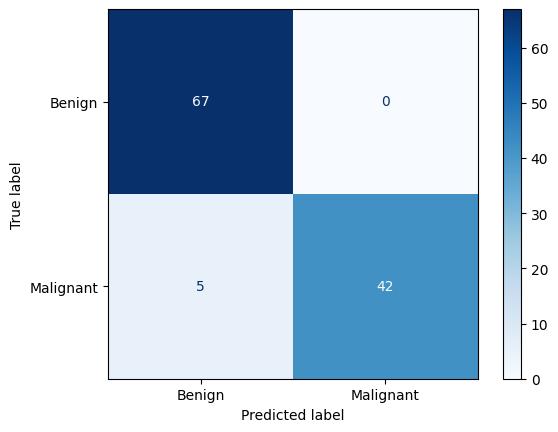

In [ ]:
# Evaluation & Visualization
cm= confusion_matrix(target_test, target_pred)
f1= f1_score(target_test, target_pred)
accuracy= accuracy_score(target_test, target_pred)
recall = recall_score(target_test, target_pred)
print("Correct Predictions: ", cm[0][0]+cm[1][1])
print("Incorrect Predictions: ", cm[0][1]+cm[1][0])
print("f1_score:", f1*100)
print("Accuracy score:", accuracy*100)
print("Recall score:", recall*100)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant']).plot(cmap='Blues')
plt.show()